# Parameterized Analysis of Multiple MGnify Studies

![MGnify](../assets/figs/mgnify_banner.png)

This notebook runs a complete bacterial diversity analysis using a configuration dictionary to control all parameters.

**Key features:**
1. Single configuration dictionary for all analysis parameters
2. Linear execution flow without code repetition
3. Conditional plot generation based on flags
4. Automated output management

**Pipeline with options**
1. Counts
2. Filter on minimum reads per sample
3. Filtering based on prok vs euk
4. Normalization `TSS`, `Rarefaction`
5. Compositional Transform `CLR`

## Setup and Imports

In [1]:
from pathlib import Path

# Dataframes and display
import pandas as pd
import numpy as np
from tqdm import tqdm

pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)

# Warning verbosity
import warnings 
warnings.filterwarnings(action="ignore")

from mgnify_methods.utils.logging import get_logger

logger = get_logger('nb_multiple_studies', level="INFO")
logger.info("Hello from mgnify_methods")
%matplotlib inline 

INFO | nb_multiple_studies | Hello from mgnify_methods


In [2]:
# Import all required functions
from momics.taxonomy import (
    fill_taxonomy_placeholders,
    rarefy_table,
)

from mgnify_methods.taxonomy import (
    aggregate_by_taxonomic_level,
    fill_lower_taxa,
    pivot_taxonomic_data,
    remove_singletons_per_sample,
)

from mgnify_methods.utils.plot import (
    plot_feature_reads_hist,
    plot_taxonomic_overlap,
    violin_plot_taxon,
)

from mgnify_methods.metacomp.rarefaction import (
    rarefaction_curve,
    calc_rarefaction_curves,
    calculate_min_rarefaction_depth,
)
from mgnify_methods.metacomp.transforms import (
    apply_preprocessing_method,
    apply_transform_method,
)
from mgnify_methods.metacomp.diversity import alpha_diversity_analysis
from mgnify_methods.utils.io import (
    load_taxonomy_summary,
    filter_tax_summary,
    assert_taxonomy_integrity,
    process_analysis_metadata,
    filter_analysis_meta,
    process_samples_metadata,
    enhance_samples_metadata,
    filter_number_reads,
)

from mgnify_methods import TaxonomyTable, AbundanceTable

# Beta diversity
from skbio.diversity import beta_diversity
from skbio.stats.ordination import pcoa

## Configuration Dictionary

All analysis parameters are defined here. Modify this dictionary to control the entire analysis flow.

In [3]:
# ============================================================================
# ANALYSIS CONFIGURATION
# ============================================================================

CONFIG = {
    # === Data Sources ===
    'datasets': {
        'OSD2018': ['MGYS00006608', 'mgnify_data/ERP124424_taxonomy_abundances_SSU_v5.0.tsv'],
        'OSD2019': ['MGYS00006607', 'mgnify_data/ERP124431_taxonomy_abundances_SSU_v5.0.tsv'],
        'Sola': ['MGYS00006680', 'mgnify_data/SRP237882_taxonomy_abundances_SSU_v5.0.tsv'],
        # 'Tara': ['MGYS00000492', 'mgnify_data/ERP003634_taxonomy_abundances_SSU_v5.0.tsv'],
        'Biscay': ['MGYS00006682', 'mgnify_data/SRP334933_taxonomy_abundances_SSU_v5.0.tsv'],
        'Baltic': ['MGYS00006678', 'mgnify_data/ERP140185_taxonomy_abundances_SSU_v5.0.tsv'],
        'BBMO': ['MGYS00006675', 'mgnify_data/ERP122219_taxonomy_abundances_SSU_v5.0.tsv'],
        'Svalbard': ['MGYS00003725', 'mgnify_data/ERP106348_taxonomy_abundances_SSU_v5.0.tsv'],
        'Helgoland': ['MGYS00006686', 'mgnify_data/ERP144826_taxonomy_abundances_SSU_v5.0.tsv'],
        'Fram': ['MGYS00006714', 'mgnify_data/ERP151329_taxonomy_abundances_SSU_v5.0.tsv'],

    },
    
    # === Output Configuration ===
    'output': {
        'use_timestamp': True,  # Create timestamped output folder
        'cache_dir': 'analysis_cache',  # Cache directory for downloaded data
    },
    
    # === Filtering Parameters ===
    'filtering': {
        'min_reads_cutoff': 25000,  # Minimum reads per sample
        # 'prevalence_percent': 0.005,  # Prevalence cutoff (0.5%)
    },
    
    # === Taxonomic Settings ===
    'taxonomy': {
        'ranks': ['superkingdom', 'kingdom', 'phylum', 'class', 'order', 'family', 'genus', 'species'],
        'analysis_level': 'phylum', #, 'class', 'order', 'family', 'genus',  # Levels for detailed analysis
        'filter_to_bacteria': True,  # Focus only on bacterial taxa
    },
    
    # === Sample Selection ===
    'samples': {
        'sample_type': 'prok',  # 'prok' or 'euk'
    },
    
    # === Preprocess Settings ===
    'preprocess': {
        'method_params': {
            'rarefaction': {
                'depth': None,  # None = auto-calculate minimum depth
                'n_points': 50,  # Number of points for rarefaction curves
            },
        },
    },
    
    # === Diversity Analysis ===
    'diversity': {
        'alpha': {
            'enabled': True,
            'dropna': False,  # Drop NA values during aggregation
            'remove_singletons': False,  # Remove taxa appearing only once per sample
            'rarefy': False,  # Rarefy samples to minimum depth before alpha diversity analysis
        },
    },
    
    # === Feature Analysis ===
    'feature': 'study_tag',  # features to analyze
    
    # === Plot Flags ===
    'plots': {
        'reads_histogram': True,
        'taxonomic_overlap_venn': True,
        'rarefaction_curves': True,
        'rarefaction_mean_std': True,
        'rarefaction_mean_ci': True,
        'rarefaction_individual': False,  # Can be very cluttered
        'alpha_diversity': True,
        'beta_diversity_pcoa': False,
        'taxa_prevalence_violin': True,
        'feature_rarefaction': True,  # Rarefaction curves per feature value
        'save_figures': False,  # Save figures to output folder
        'dpi': 300,  # DPI for saved figures
    },
}

print("Configuration loaded successfully!")
print(f"\nDatasets: {list(CONFIG['datasets'].keys())}")
print(f"Taxonomic level for analysis: {CONFIG['taxonomy']['analysis_level']}")
print(f"Feature to analyze: {CONFIG['feature']}")

Configuration loaded successfully!

Datasets: ['OSD2018', 'OSD2019', 'Sola', 'Biscay', 'Baltic', 'BBMO', 'Svalbard', 'Helgoland', 'Fram']
Taxonomic level for analysis: phylum
Feature to analyze: study_tag


## Initialize Output Directories

In [4]:
# Extract configuration
TAXONOMY_RANKS = CONFIG['taxonomy']['ranks']
ds = CONFIG['datasets']

# Create output directories
if CONFIG['output']['use_timestamp']:
    stamp = pd.Timestamp.now().strftime('%Y%m%d_%H%M')
    OUT_FOLDER = Path('analysis_' + stamp).resolve()
else:
    OUT_FOLDER = Path('analysis_latest').resolve()

ANALYSIS_CACHE = Path(CONFIG['output']['cache_dir']).resolve()

# add OUT_FOLDER to config for later use
CONFIG['output']['out_folder'] = str(OUT_FOLDER)
CONFIG['input'] = {'cache_dir': str(ANALYSIS_CACHE)}

for folder in [OUT_FOLDER, ANALYSIS_CACHE]:
    folder.mkdir(parents=True, exist_ok=True)
    print(f"Directory ready: {folder}")

# Save configuration to output folder
import json
config_path = OUT_FOLDER / 'analysis_config.json'
with open(config_path, 'w') as f:
    json.dump(CONFIG, f, indent=2)
print(f"\nConfiguration saved to: {config_path}")

Directory ready: /home/david-palecek/coding/emo-bon/mgnify-methods/mgnify-methods/notebooks/analysis_20260210_1538
Directory ready: /home/david-palecek/coding/emo-bon/mgnify-methods/mgnify-methods/notebooks/analysis_cache

Configuration saved to: /home/david-palecek/coding/emo-bon/mgnify-methods/mgnify-methods/notebooks/analysis_20260210_1538/analysis_config.json


## Load Metadata from MGnify

In [5]:
# Fetch analysis metadata
analysis_meta = process_analysis_metadata(ANALYSIS_CACHE, ds)
analysis_meta = analysis_meta.query("`attributes.pipeline-version` == 5.0")
print(f"Loaded {len(analysis_meta)} analyses")

# Fetch and enhance sample metadata
samples_meta = process_samples_metadata(ANALYSIS_CACHE, ds)
samples_meta = enhance_samples_metadata(samples_meta)
print(f"Loaded {len(samples_meta)} samples")

INFO | mgnify_methods.utils.io | Metadata file not found: Downloading...
INFO | jsonapi_client.session | Entering session
INFO | jsonapi_client.session | Fetching document from url ParseResult(scheme='https', netloc='www.ebi.ac.uk', path='/metagenomics/api/v1/studies/MGYS00006682/analyses', params='', query='', fragment='')
INFO | jsonapi_client.session | Fetching document from url ParseResult(scheme='https', netloc='www.ebi.ac.uk', path='/metagenomics/api/v1/studies/MGYS00006682/analyses', params='', query='page=2', fragment='')
INFO | jsonapi_client.session | Fetching document from url ParseResult(scheme='https', netloc='www.ebi.ac.uk', path='/metagenomics/api/v1/studies/MGYS00006682/analyses', params='', query='page=3', fragment='')
INFO | jsonapi_client.session | Exiting session
INFO | jsonapi_client.session | Committing dirty resources
INFO | mgnify_methods.utils.io | Metadata file not found: Downloading...
INFO | jsonapi_client.session | Entering session
INFO | jsonapi_client.ses

Loaded 393 analyses


0it [00:00, ?it/s]INFO | jsonapi_client.session | Fetching document from url ParseResult(scheme='https', netloc='www.ebi.ac.uk', path='/metagenomics/api/v1/studies/MGYS00006682/samples', params='', query='page_size=1000', fragment='')
52it [00:01, 36.99it/s]
INFO | jsonapi_client.session | Exiting session
INFO | jsonapi_client.session | Committing dirty resources
INFO | mgnify_methods.utils.io | Samples metadata file not found: Downloading...
INFO | jsonapi_client.session | Entering session
0it [00:00, ?it/s]INFO | jsonapi_client.session | Fetching document from url ParseResult(scheme='https', netloc='www.ebi.ac.uk', path='/metagenomics/api/v1/studies/MGYS00006678/samples', params='', query='page_size=1000', fragment='')
226it [00:02, 139.28it/s]INFO | jsonapi_client.session | Fetching document from url ParseResult(scheme='https', netloc='www.ebi.ac.uk', path='/metagenomics/api/v1/studies/MGYS00006678/samples', params='', query='page=2&page_size=1000', fragment='')
359it [00:04, 79.88i

Loaded 1859 samples


## Filter Samples by Read Count

INFO | mgnify_methods.utils.plot | sample is ERR4674051
INFO | mgnify_methods.utils.plot | sample is ERR4674187
INFO | mgnify_methods.utils.plot | sample is ERR4674176
INFO | mgnify_methods.utils.plot | sample is ERR4674164
INFO | mgnify_methods.utils.plot | sample is ERR4674155
INFO | mgnify_methods.utils.plot | sample is ERR4674141
INFO | mgnify_methods.utils.plot | sample is ERR4674128
INFO | mgnify_methods.utils.plot | sample is ERR4674113
INFO | mgnify_methods.utils.plot | sample is ERR4674098
INFO | mgnify_methods.utils.plot | sample is ERR4674084
INFO | mgnify_methods.utils.plot | sample is ERR4674076
INFO | mgnify_methods.utils.plot | sample is ERR4674073
INFO | mgnify_methods.utils.plot | sample is ERR4674046
INFO | mgnify_methods.utils.plot | sample is ERR4674043
INFO | mgnify_methods.utils.plot | sample is ERR4674038
INFO | mgnify_methods.utils.plot | sample is ERR4674207
INFO | mgnify_methods.utils.plot | sample is ERR4674190
INFO | mgnify_methods.utils.plot | sample is ERR


=== Reads Distribution (Unfiltered) ===


INFO | mgnify_methods.utils.plot | sample is ERR4674725
INFO | mgnify_methods.utils.plot | sample is ERR4674677
INFO | mgnify_methods.utils.plot | sample is ERR4674728
INFO | mgnify_methods.utils.plot | sample is ERR4674698
INFO | mgnify_methods.utils.plot | sample is ERR4674646
INFO | mgnify_methods.utils.plot | sample is ERR4674692
INFO | mgnify_methods.utils.plot | sample is ERR4674722
INFO | mgnify_methods.utils.plot | sample is ERR4674689
INFO | mgnify_methods.utils.plot | sample is ERR4674643
INFO | mgnify_methods.utils.plot | sample is ERR4674757
INFO | mgnify_methods.utils.plot | sample is ERR4674719
INFO | mgnify_methods.utils.plot | sample is ERR4674742
INFO | mgnify_methods.utils.plot | sample is ERR4674671
INFO | mgnify_methods.utils.plot | sample is ERR4674716
INFO | mgnify_methods.utils.plot | sample is ERR4674707
INFO | mgnify_methods.utils.plot | sample is ERR4674710
INFO | mgnify_methods.utils.plot | sample is ERR4674695
INFO | mgnify_methods.utils.plot | sample is ERR

Samples not matched to study_tag metadata: 0


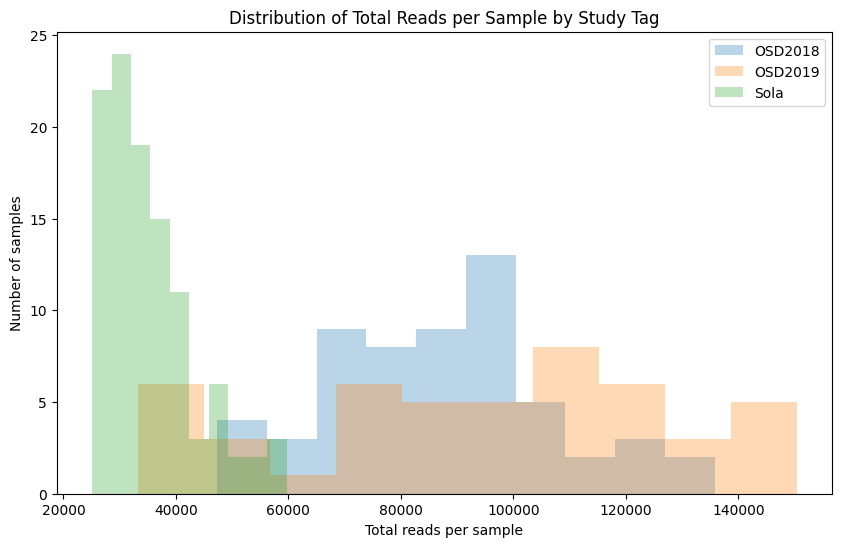

INFO | mgnify_methods.utils.io | Dropping 0 samples with less than 25000 reads: []
INFO | mgnify_methods.utils.plot | sample is ERR4674051
INFO | mgnify_methods.utils.plot | sample is ERR4674187
INFO | mgnify_methods.utils.plot | sample is ERR4674176
INFO | mgnify_methods.utils.plot | sample is ERR4674164
INFO | mgnify_methods.utils.plot | sample is ERR4674155
INFO | mgnify_methods.utils.plot | sample is ERR4674141
INFO | mgnify_methods.utils.plot | sample is ERR4674128
INFO | mgnify_methods.utils.plot | sample is ERR4674113
INFO | mgnify_methods.utils.plot | sample is ERR4674098
INFO | mgnify_methods.utils.plot | sample is ERR4674084
INFO | mgnify_methods.utils.plot | sample is ERR4674076
INFO | mgnify_methods.utils.plot | sample is ERR4674073
INFO | mgnify_methods.utils.plot | sample is ERR4674046
INFO | mgnify_methods.utils.plot | sample is ERR4674043
INFO | mgnify_methods.utils.plot | sample is ERR4674038
INFO | mgnify_methods.utils.plot | sample is ERR4674207
INFO | mgnify_methods


Filtering samples with < 25000 reads: 0 samples to remove
Remaining analyses after filtering: 213

=== Reads Distribution (Filtered) ===


INFO | mgnify_methods.utils.plot | sample is ERR4674056
INFO | mgnify_methods.utils.plot | sample is ERR4674053
INFO | mgnify_methods.utils.plot | sample is ERR4674205
INFO | mgnify_methods.utils.plot | sample is ERR4674202
INFO | mgnify_methods.utils.plot | sample is ERR4674199
INFO | mgnify_methods.utils.plot | sample is ERR4674196
INFO | mgnify_methods.utils.plot | sample is ERR4674193
INFO | mgnify_methods.utils.plot | sample is ERR4674173
INFO | mgnify_methods.utils.plot | sample is ERR4674157
INFO | mgnify_methods.utils.plot | sample is ERR4674149
INFO | mgnify_methods.utils.plot | sample is ERR4674143
INFO | mgnify_methods.utils.plot | sample is ERR4674138
INFO | mgnify_methods.utils.plot | sample is ERR4674135
INFO | mgnify_methods.utils.plot | sample is ERR4674125
INFO | mgnify_methods.utils.plot | sample is ERR4674119
INFO | mgnify_methods.utils.plot | sample is ERR4674110
INFO | mgnify_methods.utils.plot | sample is ERR4674104
INFO | mgnify_methods.utils.plot | sample is ERR

Samples not matched to study_tag metadata: 0


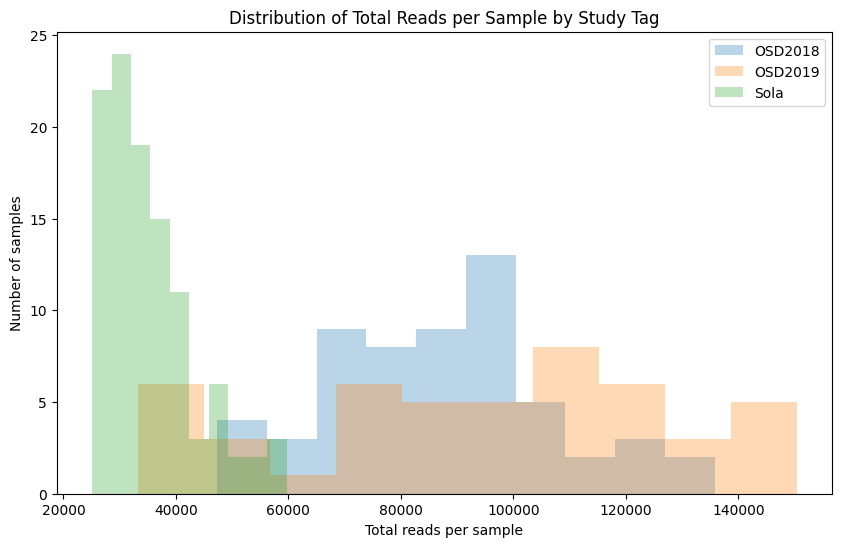

In [22]:
# Plot reads distribution before filtering
if CONFIG['plots']['reads_histogram']:
    print("\n=== Reads Distribution (Unfiltered) ===")
    total_dict = plot_feature_reads_hist(
        analysis_meta=analysis_meta,
        samples_meta=samples_meta,
        feature=CONFIG['feature'],
        name=f'{CONFIG["feature"]}_reads_unfiltered.png' if CONFIG['plots']['save_figures'] else None,
        out_dir=OUT_FOLDER if CONFIG['plots']['save_figures'] else None,
        use_robust_save=False,
    )

# Apply filtering
cutoff = CONFIG['filtering']['min_reads_cutoff']
to_drop = filter_number_reads(total_dict, cutoff)
print(f"\nFiltering samples with < {cutoff} reads: {len(to_drop)} samples to remove")

for sample in to_drop:
    analysis_meta = analysis_meta[analysis_meta.index != sample]

print(f"Remaining analyses after filtering: {len(analysis_meta)}")

# Plot reads distribution after filtering
if CONFIG['plots']['reads_histogram']:
    print("\n=== Reads Distribution (Filtered) ===")
    total_dict = plot_feature_reads_hist(
        analysis_meta=analysis_meta,
        samples_meta=samples_meta,
        feature=CONFIG['feature'],
        name=f'{CONFIG["feature"]}_reads_unfiltered.png' if CONFIG['plots']['save_figures'] else None,
        out_dir=OUT_FOLDER if CONFIG['plots']['save_figures'] else None,
        use_robust_save=False,
    )

## Load and Merge Taxonomy Data

In [7]:
# Get data folder path
root_folder = Path.cwd().parent
data_folder = root_folder / 'data'

df_tax_summary = load_taxonomy_summary(ds, data_folder)

INFO | mgnify_methods.utils.io | Loaded OSD2018: (1981, 62)
INFO | mgnify_methods.utils.io | Loaded OSD2019: (1708, 48)
INFO | mgnify_methods.utils.io | Loaded Sola: (3484, 283)
INFO | mgnify_methods.utils.io | Loaded Biscay: (118, 52)
INFO | mgnify_methods.utils.io | Loaded Baltic: (4316, 665)
INFO | mgnify_methods.utils.io | Loaded BBMO: (2503, 249)
INFO | mgnify_methods.utils.io | Loaded Svalbard: (1505, 81)
INFO | mgnify_methods.utils.io | Loaded Helgoland: (2241, 165)
INFO | mgnify_methods.utils.io | Loaded Fram: (1428, 205)
INFO | mgnify_methods.utils.io | 
Merged taxonomy table: (7265, 1810)


## Synchronize Metadata and Taxonomy Tables

In [8]:
# Remove samples not in metadata
analysis_meta = filter_analysis_meta(analysis_meta, samples_meta)
df_tax_summary = filter_tax_summary(df_tax_summary, analysis_meta)

# check data integrity
assert_taxonomy_integrity(df_tax_summary, analysis_meta)

INFO | mgnify_methods.utils.io | Dropped 143 samples from analysis_meta: 356 -> 213
INFO | mgnify_methods.utils.io | 
Taxonomy samples before filtering: 1810
INFO | mgnify_methods.utils.io | 
Taxonomy samples before filtering: 1810
INFO | mgnify_methods.utils.io | Taxonomy samples after filtering: 213
INFO | mgnify_methods.utils.io | 
Removing 4797 taxa with all zero counts
INFO | mgnify_methods.utils.io | 
✓ Data tables synchronized successfully


## Convert to TaxonomyTable Format

In [9]:
# Convert abundance table to taxonomy table
abundance_table = AbundanceTable(df_tax_summary.reset_index(), source='tax_mgnify_raw')
ncbi_flag, taxonomy_table = abundance_table.to_taxonomy_table()

taxonomy_table.df.sort_values(by=['source material ID', 'abundance'], inplace=True)

# Fill missing taxonomic information
taxonomy_table.df = fill_lower_taxa(taxonomy_table.df, TAXONOMY_RANKS)
taxonomy_table.df = fill_taxonomy_placeholders(taxonomy_table.df, TAXONOMY_RANKS)

if not taxonomy_table.df.index.name == 'source material ID':
    taxonomy_table.df = taxonomy_table.df.set_index('source material ID')

print(f"\nTaxonomy table ready: {taxonomy_table.df.shape}")

INFO | mgnify_methods.tables.tables | Converting source: tax_mgnify_raw
WARNING | mgnify_methods.tables.tables | DataFrame is abundance without ncbi_tax_id data.
INFO | mgnify_methods.tables.tables | self.source before conversion to Taxonomy table: tax_mgnify_raw
INFO | mgnify_methods.tables.tables | Converting source: tax_processed
INFO | mgnify_methods.tables.sources.converters | Abundance dtype after conversion: uint16
INFO | mgnify_methods.tables.tables | Validating source: tax_processed



Taxonomy table ready: (63558, 9)


## Filter to Target Sample Type
- either `prok` or `euk`

In [10]:
# Get sample list for selected sample type
sample_type = CONFIG['samples']['sample_type']
sample_list = samples_meta[samples_meta['sample_type'] == sample_type]['id'].tolist()
data_list = analysis_meta[analysis_meta['relationships.sample.data.id'].isin(sample_list)].index.tolist()

# Filter taxonomy table
taxonomy_table.df_filt = taxonomy_table.df[taxonomy_table.df.index.isin(data_list)]

print(f"Filtered to {sample_type} samples: {len(data_list)} samples")
print(f"Filtered taxonomy table: {taxonomy_table.df_filt.shape}")

Filtered to prok samples: 213 samples
Filtered taxonomy table: (63558, 9)


## Taxonomic Overlap Analysis

In [11]:
# if CONFIG['plots']['taxonomic_overlap_venn']:
#     logger.info("\n=== Taxonomic Overlap Analysis ===")
#     plot_taxonomic_overlap(taxonomy_table, analysis_meta, CONFIG)

## Preprocessing
- aggregate by taxonomic level (this is done on the Taxonomy table)
- then convert to abundance table
- then prevalence cutoff
- then preprocessing normlization `rarefaction`, `tss`, `tss_sqrt`

**This is supposed to be rewritten using only the OOP TaxonomyTable and AbendanceTable**

In [12]:
tax_level = CONFIG['taxonomy']['analysis_level']
table = aggregate_by_taxonomic_level(
    taxonomy_table.df_filt, level=tax_level, dropna=CONFIG['diversity']['alpha']['dropna']
)

In [13]:
abundance_table = pivot_taxonomic_data(table)
type(abundance_table)

pandas.core.frame.DataFrame

## Apha diversity analysis
- Needs to be on counts

**Three cases**
1. No additional preprocessing
2. Only removing singletons
3. Only rarefaction

Both removing singletons and rarefaction is not recommended

In [14]:
tax_level = CONFIG['taxonomy']['analysis_level']

### Case 1, no preprocessing

INFO | mgnify_methods.metacomp.diversity | 
=== Alpha Diversity Analysis ===
INFO | mgnify_methods.metacomp.diversity | Analyzing at phylum level...
INFO | mgnify_methods.metacomp.diversity | Data: 213 samples, 146 taxa
INFO | mgnify_methods.metacomp.diversity | Study distribution: {'Sola': 107, 'OSD2018': 58, 'OSD2019': 48}
INFO | mgnify_methods.metacomp.diversity | 
Saved diversity results to: /home/david-palecek/coding/emo-bon/mgnify-methods/mgnify-methods/notebooks/analysis_20260210_1538/alpha_diversity_phylum_no_processing.csv


Calculated diversity for 213 samples


shannon                                                  simpson  \
            count   mean    std    min    25%    50%    75%    max   count   
study_tag                                                                    
OSD2018      58.0  1.458  0.285  0.506  1.296  1.490  1.647  1.926    58.0   
OSD2019      48.0  1.352  0.219  0.843  1.178  1.384  1.502  1.765    48.0   
Sola        107.0  1.347  0.165  0.900  1.238  1.379  1.476  1.681   107.0   

                                                           observed_otus  \
            mean    std    min    25%    50%    75%    max         count   
study_tag                                                                  
OSD2018    0.675  0.116  0.222  0.627  0.698  0.749  0.833          58.0   
OSD2019    0.634  0.096  0.365  0.572  0.657  0.701  0.771          48.0   
Sola       0.617  0.068  0.393  0.573  0.625  0.672  0.742         107.0   

                                                          chao1          \
             mean     std   min    25%   50%   75%   max  count    mean   
study_tag                                                                 
OSD2018    38.759  13.334  11.0  30.25  37.5  48.0  71.0   58.0  46.717   
OSD2019    42.792  16.856  15.0  30.00  44.5  56.0  80.0   48.0  51.432   
Sola       32.720   8.882  19.0  27.00  31.0  36.0  70.0  107.0  45.773   

                                                        
              std   min     25%     50%     75%    max  
study_tag                                               
OSD2018    17.577  11.0  34.850  46.071  55.469  114.5  
OSD2019    21.667  17.5  34.025  54.814  63.000  120.5  
Sola       16.522  22.2  33.417  42.250  53.550  100.0

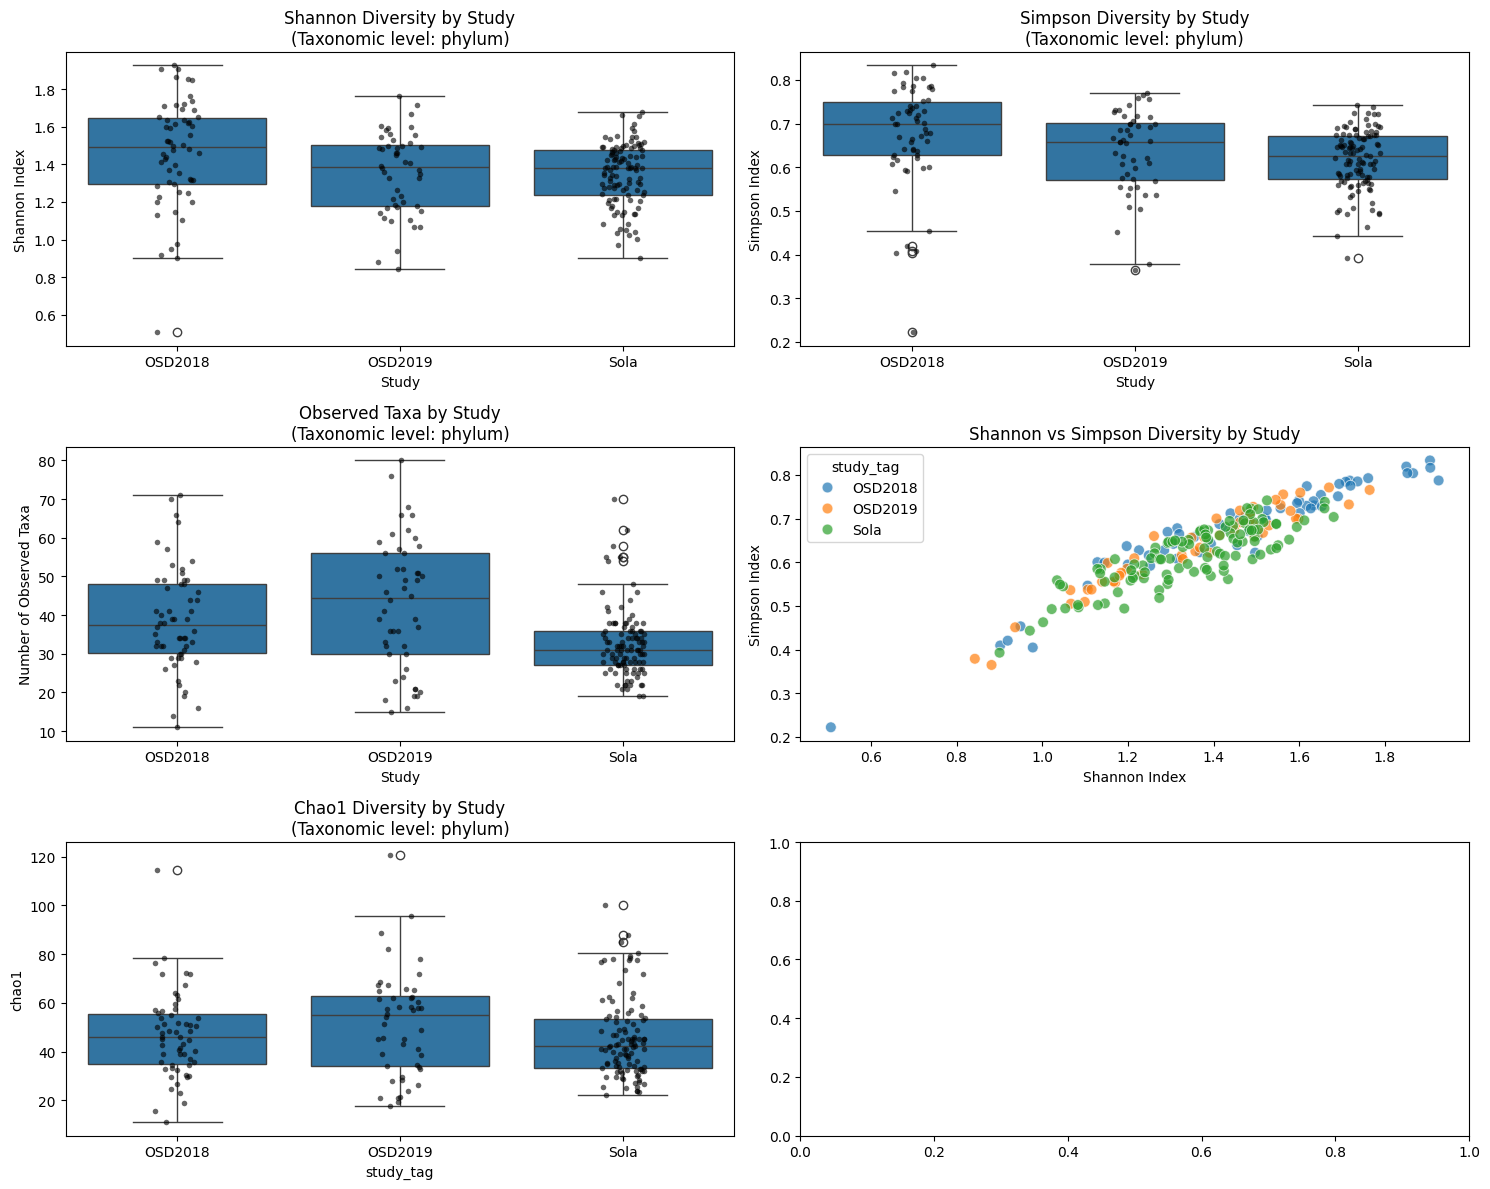

INFO | mgnify_methods.stats | 
INFO | mgnify_methods.stats | STATISTICAL COMPARISON OF ALPHA DIVERSITY BETWEEN STUDIES
INFO | mgnify_methods.stats | ============================================================
INFO | mgnify_methods.stats | 
SHANNON - Kruskal-Wallis
INFO | mgnify_methods.stats | H=11.453, p=0.0033, epsilon²=0.045
INFO | mgnify_methods.stats | 
SIMPSON - Kruskal-Wallis
INFO | mgnify_methods.stats | H=23.810, p=0.0000, epsilon²=0.104
INFO | mgnify_methods.stats | 
OBSERVED_OTUS - Kruskal-Wallis
INFO | mgnify_methods.stats | H=19.049, p=0.0001, epsilon²=0.081
INFO | mgnify_methods.stats | 
CHAO1 - Kruskal-Wallis
INFO | mgnify_methods.stats | H=3.279, p=0.1940, epsilon²=0.006


,Metric,Comparison,Test,Statistic,RawP,DeltaMedian,RBC,CliffDelta,KW_H,KW_P,KW_EpsilonSq,AdjP
0,shannon,OSD2018 vs OSD2019,Pairwise MW,1765.0,0.018067,0.105492,-0.267960,0.267960,11.453436,0.003258,0.045016,0.036135
1,shannon,OSD2018 vs Sola,Pairwise MW,4074.0,0.000925,0.111266,-0.312923,0.312923,11.453436,0.003258,0.045016,0.002776
2,shannon,OSD2019 vs Sola,Pairwise MW,2678.0,0.671734,0.005774,-0.042835,0.042835,11.453436,0.003258,0.045016,0.671734
3,simpson,OSD2018 vs OSD2019,Pairwise MW,1803.0,0.009176,0.040983,-0.295259,0.295259,23.809914,0.000007,0.103857,0.018352
4,simpson,OSD2018 vs Sola,Pairwise MW,4520.0,0.000001,0.073539,-0.456655,0.456655,23.809914,0.000007,0.103857,0.000004
5,simpson,OSD2019 vs Sola,Pairwise MW,3024.0,0.077933,0.032556,-0.177570,0.177570,23.809914,0.000007,0.103857,0.077933
6,observed_otus,OSD2018 vs OSD2019,Pairwise MW,1183.5,0.186590,-7.000000,0.149784,-0.149784,19.049487,0.000073,0.081188,0.186590
7,observed_otus,OSD2018 vs Sola,Pairwise MW,4101.0,0.000656,6.500000,-0.321624,0.321624,19.049487,0.000073,0.081188,0.001312
8,observed_otus,OSD2019 vs Sola,Pairwise MW,3495.5,0.000331,13.500000,-0.361176,0.361176,19.049487,0.000073,0.081188,0.000993
9,chao1,OSD2018 vs OSD2019,Pairwise MW,1194.0,0.210010,-8.742857,0.142241,-0.142241,3.279317,0.194046,0.006092,0.420019


In [15]:
CONFIG['output']['alpha_tag'] = 'no_processing'
summary_case1, df_case1, stats_case1 = alpha_diversity_analysis(
    abundance_table, analysis_meta, 
    samples_meta, CONFIG,
)

### Case 2, remove singletons

INFO | nb_multiple_studies | Removed singletons per sample
INFO | mgnify_methods.metacomp.diversity | 
=== Alpha Diversity Analysis ===
INFO | mgnify_methods.metacomp.diversity | Analyzing at phylum level...
INFO | mgnify_methods.metacomp.diversity | Data: 213 samples, 113 taxa
INFO | mgnify_methods.metacomp.diversity | Study distribution: {'Sola': 107, 'OSD2018': 58, 'OSD2019': 48}
INFO | mgnify_methods.metacomp.diversity | 
Saved diversity results to: /home/david-palecek/coding/emo-bon/mgnify-methods/mgnify-methods/notebooks/analysis_20260210_1538/alpha_diversity_phylum_remove_singletons.csv


Removed 33 singleton features. Shape reduced from (146, 213) → (113, 213)
Calculated diversity for 213 samples


shannon                                                  simpson  \
            count   mean    std    min    25%    50%    75%    max   count   
study_tag                                                                    
OSD2018      58.0  1.456  0.285  0.506  1.291  1.488  1.645  1.923    58.0   
OSD2019      48.0  1.350  0.219  0.841  1.176  1.382  1.500  1.762    48.0   
Sola        107.0  1.343  0.165  0.897  1.234  1.376  1.471  1.676   107.0   

                                                           observed_otus  \
            mean    std    min    25%    50%    75%    max         count   
study_tag                                                                  
OSD2018    0.675  0.116  0.222  0.627  0.698  0.748  0.833          58.0   
OSD2019    0.634  0.096  0.365  0.572  0.657  0.701  0.771          48.0   
Sola       0.617  0.068  0.392  0.573  0.624  0.671  0.741         107.0   

                                                           chao1          \
             mean     std   min    25%   50%    75%   max  count    mean   
study_tag                                                                  
OSD2018    30.586  12.189  11.0  22.25  28.0  38.75  61.0   58.0  30.586   
OSD2019    33.750  15.098  11.0  22.00  32.5  44.00  67.0   48.0  33.750   
Sola       22.645   6.464  13.0  19.00  22.0  25.50  54.0  107.0  22.645   

                                                   
              std   min    25%   50%    75%   max  
study_tag                                          
OSD2018    12.189  11.0  22.25  28.0  38.75  61.0  
OSD2019    15.098  11.0  22.00  32.5  44.00  67.0  
Sola        6.464  13.0  19.00  22.0  25.50  54.0

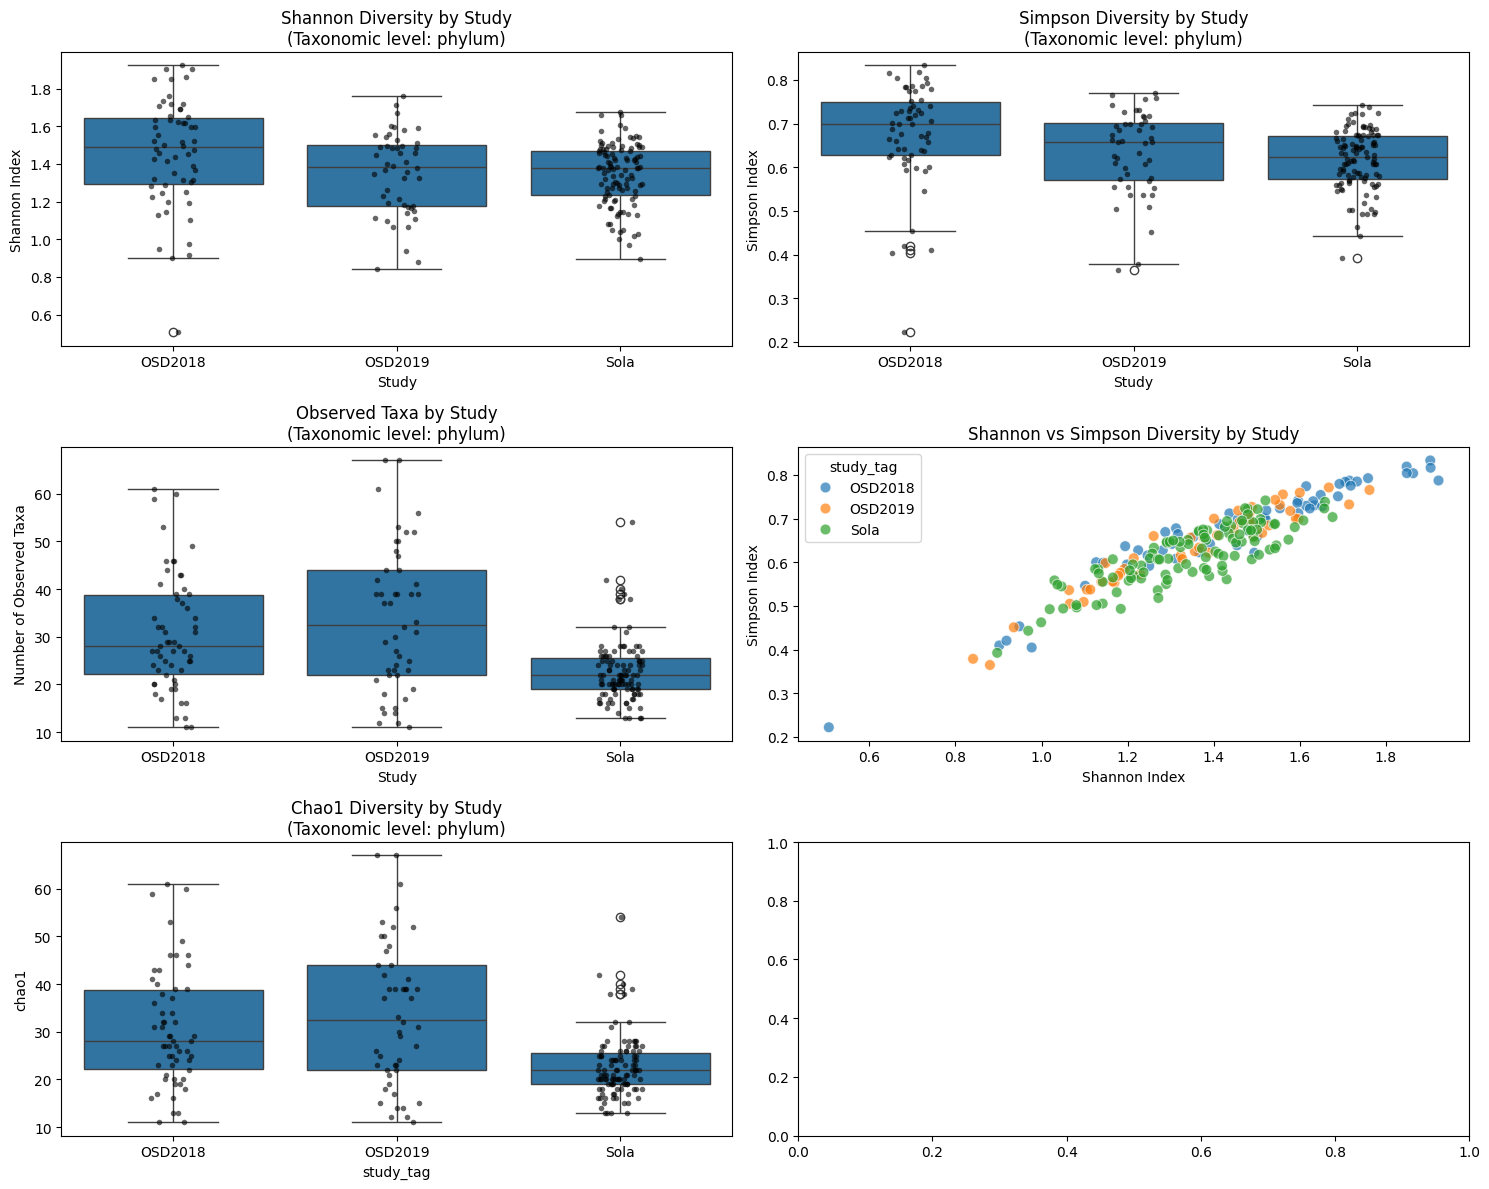

INFO | mgnify_methods.stats | 
INFO | mgnify_methods.stats | STATISTICAL COMPARISON OF ALPHA DIVERSITY BETWEEN STUDIES
INFO | mgnify_methods.stats | ============================================================
INFO | mgnify_methods.stats | 
SHANNON - Kruskal-Wallis
INFO | mgnify_methods.stats | H=11.730, p=0.0028, epsilon²=0.046
INFO | mgnify_methods.stats | 
SIMPSON - Kruskal-Wallis
INFO | mgnify_methods.stats | H=23.823, p=0.0000, epsilon²=0.104
INFO | mgnify_methods.stats | 
OBSERVED_OTUS - Kruskal-Wallis
INFO | mgnify_methods.stats | H=29.909, p=0.0000, epsilon²=0.133
INFO | mgnify_methods.stats | 
CHAO1 - Kruskal-Wallis
INFO | mgnify_methods.stats | H=29.909, p=0.0000, epsilon²=0.133


,Metric,Comparison,Test,Statistic,RawP,DeltaMedian,RBC,CliffDelta,KW_H,KW_P,KW_EpsilonSq,AdjP
0,shannon,OSD2018 vs OSD2019,Pairwise MW,1767.0,0.017458,0.105704,-0.269397,0.269397,11.729927,2.837127e-03,0.046333,0.034915
1,shannon,OSD2018 vs Sola,Pairwise MW,4085.0,0.000809,0.112188,-0.316468,0.316468,11.729927,2.837127e-03,0.046333,0.002426
2,shannon,OSD2019 vs Sola,Pairwise MW,2698.0,0.616251,0.006484,-0.050623,0.050623,11.729927,2.837127e-03,0.046333,0.616251
3,simpson,OSD2018 vs OSD2019,Pairwise MW,1802.0,0.009348,0.040944,-0.294540,0.294540,23.823058,6.712568e-06,0.103919,0.018695
4,simpson,OSD2018 vs Sola,Pairwise MW,4520.0,0.000001,0.073664,-0.456655,0.456655,23.823058,6.712568e-06,0.103919,0.000004
5,simpson,OSD2019 vs Sola,Pairwise MW,3027.0,0.075995,0.032719,-0.178738,0.178738,23.823058,6.712568e-06,0.103919,0.075995
6,observed_otus,OSD2018 vs OSD2019,Pairwise MW,1244.5,0.350564,-4.500000,0.105963,-0.105963,29.909472,3.200669e-07,0.132902,0.350564
7,observed_otus,OSD2018 vs Sola,Pairwise MW,4442.5,0.000005,6.000000,-0.431679,0.431679,29.909472,3.200669e-07,0.132902,0.000014
8,observed_otus,OSD2019 vs Sola,Pairwise MW,3677.0,0.000017,10.500000,-0.431854,0.431854,29.909472,3.200669e-07,0.132902,0.000035
9,chao1,OSD2018 vs OSD2019,Pairwise MW,1244.5,0.350564,-4.500000,0.105963,-0.105963,29.909472,3.200669e-07,0.132902,0.350564


In [16]:
abundance_table_alpha = abundance_table.copy()
abundance_table_alpha = remove_singletons_per_sample(abundance_table_alpha, skip_columns=0)
logger.info("Removed singletons per sample")

CONFIG['output']['alpha_tag'] = 'remove_singletons'
summary_case2, df_case2, stats_case2 = alpha_diversity_analysis(abundance_table_alpha, analysis_meta, samples_meta, CONFIG)

### Case 3, Rarefy

INFO | nb_multiple_studies | 
=== Calculating Minimum Rarefaction Depth ===
INFO | mgnify_methods.metacomp.rarefaction | Minimum rarefaction depth: 14591
INFO | nb_multiple_studies | Minimum rarefaction depth determined: 14591 reads
INFO | mgnify_methods.metacomp.diversity | 
=== Alpha Diversity Analysis ===
INFO | mgnify_methods.metacomp.diversity | Analyzing at phylum level...
INFO | mgnify_methods.metacomp.diversity | Data: 213 samples, 146 taxa


Minimum rarefaction depth: 14591
Minimum rarefaction depth: 14591


INFO | mgnify_methods.metacomp.diversity | Study distribution: {'Sola': 107, 'OSD2018': 58, 'OSD2019': 48}
INFO | mgnify_methods.metacomp.diversity | 
Saved diversity results to: /home/david-palecek/coding/emo-bon/mgnify-methods/mgnify-methods/notebooks/analysis_20260210_1538/alpha_diversity_phylum_rarefied.csv


Calculated diversity for 213 samples


shannon                                                  simpson  \
            count   mean    std    min    25%    50%    75%    max   count   
study_tag                                                                    
OSD2018      58.0  1.456  0.286  0.504  1.293  1.489  1.648  1.934    58.0   
OSD2019      48.0  1.350  0.217  0.856  1.176  1.381  1.505  1.759    48.0   
Sola        107.0  1.347  0.164  0.914  1.239  1.379  1.478  1.676   107.0   

                                                           observed_otus  \
            mean    std    min    25%    50%    75%    max         count   
study_tag                                                                  
OSD2018    0.675  0.116  0.221  0.627  0.699  0.747  0.834          58.0   
OSD2019    0.634  0.095  0.366  0.574  0.657  0.702  0.771          48.0   
Sola       0.617  0.068  0.399  0.573  0.630  0.670  0.742         107.0   

                                                           chao1          \
             mean     std   min    25%   50%    75%   max  count    mean   
study_tag                                                                  
OSD2018    30.776  11.448  11.0  23.00  28.5  39.00  60.0   58.0  39.625   
OSD2019    32.875  13.287  12.0  24.25  33.0  41.25  67.0   48.0  43.314   
Sola       26.607   7.269  15.0  22.00  26.0  29.50  61.0  107.0  37.253   

                                                            
              std     min     25%     50%     75%      max  
study_tag                                                   
OSD2018    16.738  11.000  29.050  34.583  50.775   94.000  
OSD2019    18.452  12.333  32.425  44.500  52.781  103.333  
Sola       14.490  18.000  28.000  33.600  41.600  119.000

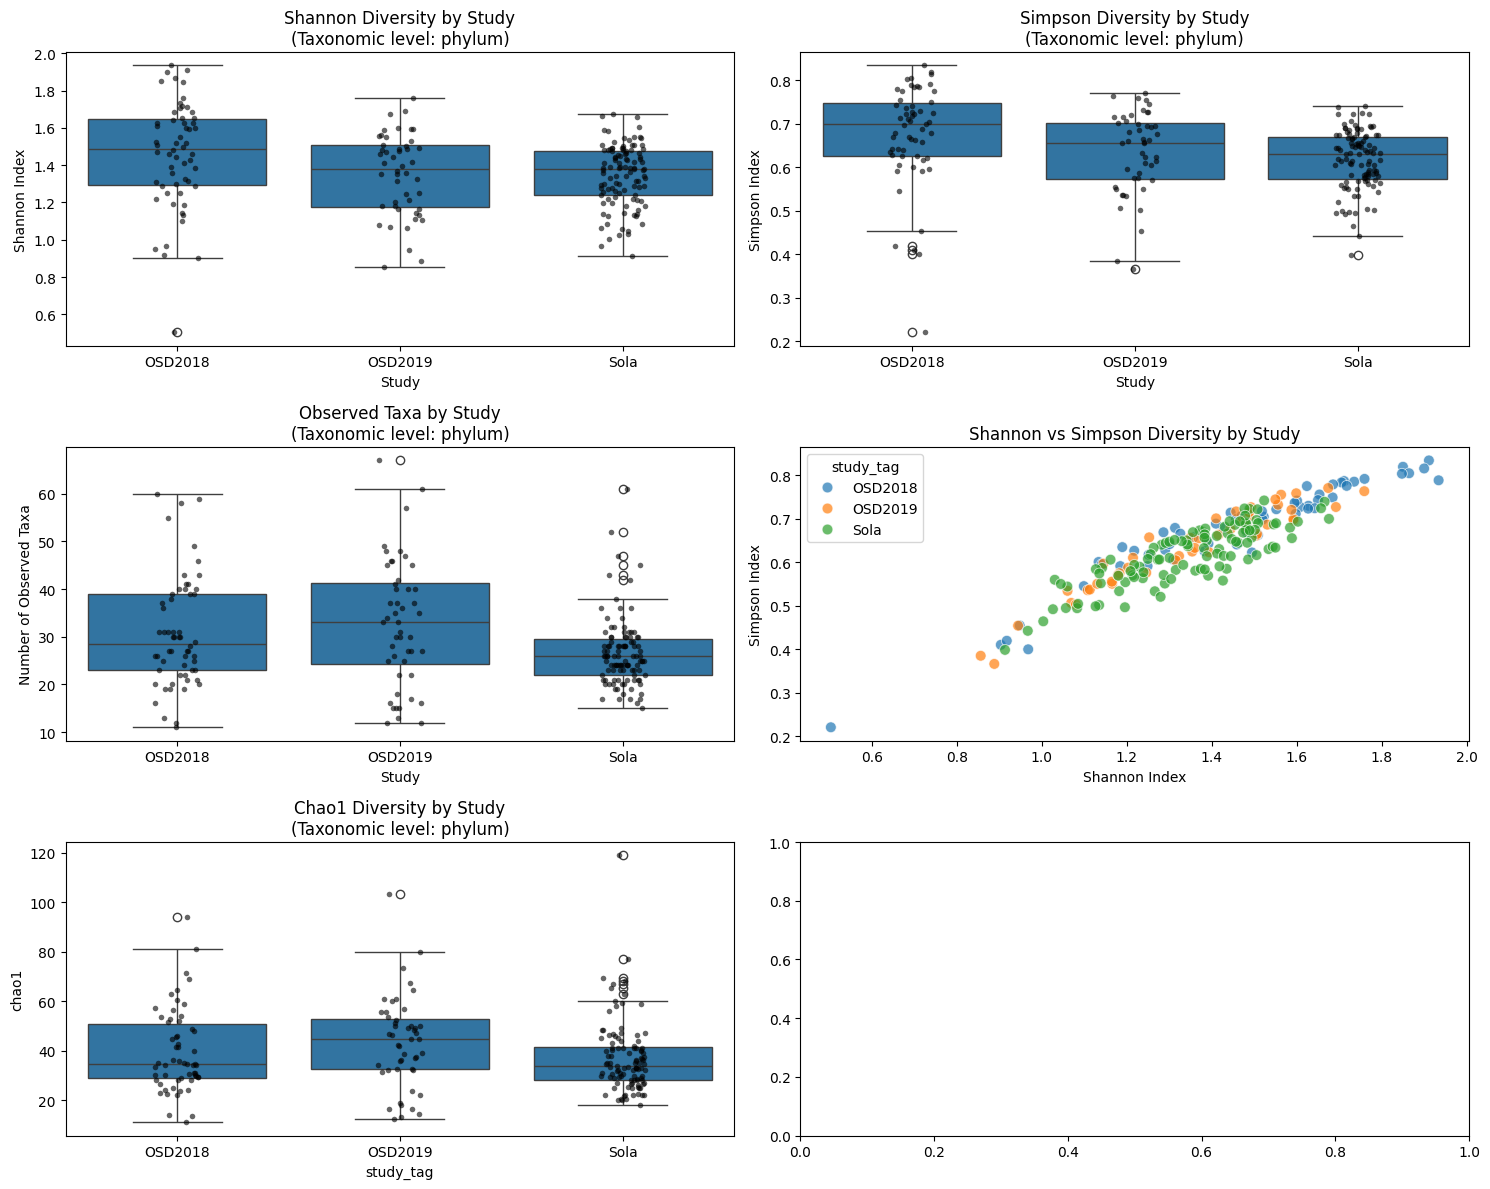

INFO | mgnify_methods.stats | 
INFO | mgnify_methods.stats | STATISTICAL COMPARISON OF ALPHA DIVERSITY BETWEEN STUDIES
INFO | mgnify_methods.stats | ============================================================
INFO | mgnify_methods.stats | 
SHANNON - Kruskal-Wallis
INFO | mgnify_methods.stats | H=11.789, p=0.0028, epsilon²=0.047
INFO | mgnify_methods.stats | 
SIMPSON - Kruskal-Wallis
INFO | mgnify_methods.stats | H=23.975, p=0.0000, epsilon²=0.105
INFO | mgnify_methods.stats | 
OBSERVED_OTUS - Kruskal-Wallis
INFO | mgnify_methods.stats | H=11.408, p=0.0033, epsilon²=0.045
INFO | mgnify_methods.stats | 
CHAO1 - Kruskal-Wallis
INFO | mgnify_methods.stats | H=6.487, p=0.0390, epsilon²=0.021


,Metric,Comparison,Test,Statistic,RawP,DeltaMedian,RBC,CliffDelta,KW_H,KW_P,KW_EpsilonSq,AdjP
0,shannon,OSD2018 vs OSD2019,Pairwise MW,1775.0,0.015195,0.107097,-0.275144,0.275144,11.789299,0.002754,0.046616,0.030390
1,shannon,OSD2018 vs Sola,Pairwise MW,4084.0,0.000819,0.109975,-0.316146,0.316146,11.789299,0.002754,0.046616,0.002456
2,shannon,OSD2019 vs Sola,Pairwise MW,2681.0,0.663287,0.002878,-0.044003,0.044003,11.789299,0.002754,0.046616,0.663287
3,simpson,OSD2018 vs OSD2019,Pairwise MW,1809.0,0.008205,0.041832,-0.299569,0.299569,23.974889,0.000006,0.104642,0.016411
4,simpson,OSD2018 vs Sola,Pairwise MW,4523.0,0.000001,0.068333,-0.457622,0.457622,23.974889,0.000006,0.104642,0.000004
5,simpson,OSD2019 vs Sola,Pairwise MW,3023.0,0.078589,0.026502,-0.177181,0.177181,23.974889,0.000006,0.104642,0.078589
6,observed_otus,OSD2018 vs OSD2019,Pairwise MW,1242.5,0.343967,-4.500000,0.107399,-0.107399,11.407855,0.003333,0.044799,0.343967
7,observed_otus,OSD2018 vs Sola,Pairwise MW,3765.0,0.023767,2.500000,-0.213342,0.213342,11.407855,0.003333,0.044799,0.047534
8,observed_otus,OSD2019 vs Sola,Pairwise MW,3367.5,0.001964,7.000000,-0.311332,0.311332,11.407855,0.003333,0.044799,0.005893
9,chao1,OSD2018 vs OSD2019,Pairwise MW,1168.5,0.156948,-9.916667,0.160560,-0.160560,6.486777,0.039031,0.021366,0.313897


In [17]:
abundance_table_alpha = abundance_table.copy()

logger.info("\n=== Calculating Minimum Rarefaction Depth ===")
MIN_DEPTH = calculate_min_rarefaction_depth(abundance_table_alpha)
logger.info(f"Minimum rarefaction depth determined: {MIN_DEPTH} reads")

abundance_table_alpha = rarefy_table(abundance_table_alpha, depth=MIN_DEPTH)


CONFIG['output']['alpha_tag'] = 'rarefied'
summary_case3, df_case3, stats_case3 = alpha_diversity_analysis(abundance_table_alpha, 
                                                   analysis_meta, samples_meta,
                                                   CONFIG)

## Comparison between treatments
- construct table like this

| Pipeline     | Metric  | Δmedian | Effect size | p     | Direction |
| ------------ | ------- | ------- | ----------- | ----- | --------- |
| Raw counts   | Shannon | +0.11   | 0.28        | 0.001 | OSD>SOLA  |
| CLR filtered | Shannon | +0.08   | 0.21        | 0.02  | OSD>SOLA  |
| Rarefied     | Shannon | +0.10   | 0.26        | 0.003 | OSD>SOLA  |

- calculate delta medians and effect sizes


In [18]:
# summary_case1.head()

In [19]:
# df_case1.head()

In [20]:
# stats_case1.head()

### Combine per metric

In [21]:
df = pd.concat([stats_case1, stats_case2, stats_case3], axis=0)

shannon_stats = df[df['Metric'] == 'shannon']
shannon_stats.index = ['No Processing', 'Remove Singletons', 'Rarefied']
shannon_stats.head()


ValueError: Length mismatch: Expected axis has 9 elements, new values have 3 elements

In [ ]:
simpson_stats = df[df['Metric'] == 'simpson']
simpson_stats.index = ['No Processing', 'Remove Singletons', 'Rarefied']
simpson_stats.head()

,Metric,median OSD2018,median Sola,Delta Median,Rank Biserial Correlation,CliffDelta,U-Statistic,P-Value,direction
No Processing,simpson,0.698329,0.624790,0.073539,-0.456655,0.456655,4520.0,0.000001,OSD2018 > Sola
Remove Singletons,simpson,0.698154,0.624490,0.073664,-0.456655,0.456655,4520.0,0.000001,OSD2018 > Sola
Rarefied,simpson,0.697186,0.626994,0.070192,-0.457622,0.457622,4523.0,0.000001,OSD2018 > Sola


In [ ]:
otus_stats = df[df['Metric'] == 'observed_otus']
otus_stats.index = ['No Processing', 'Remove Singletons', 'Rarefied']
otus_stats.head()

,Metric,median OSD2018,median Sola,Delta Median,Rank Biserial Correlation,CliffDelta,U-Statistic,P-Value,direction
No Processing,observed_otus,37.5,31.0,6.5,-0.321624,0.321624,4101.0,0.000656,OSD2018 > Sola
Remove Singletons,observed_otus,28.0,22.0,6.0,-0.431679,0.431679,4442.5,0.000005,OSD2018 > Sola
Rarefied,observed_otus,29.0,26.0,3.0,-0.193039,0.193039,3702.0,0.040747,OSD2018 > Sola


In [ ]:
chao1_stats = df[df['Metric'] == 'chao1']
chao1_stats.index = ['No Processing', 'Remove Singletons', 'Rarefied']
chao1_stats.head()

,Metric,median OSD2018,median Sola,Delta Median,Rank Biserial Correlation,CliffDelta,U-Statistic,P-Value,direction
No Processing,chao1,46.071429,42.25,3.821429,-0.069771,0.069771,3319.5,0.460984,OSD2018 > Sola
Remove Singletons,chao1,28.000000,22.00,6.000000,-0.431679,0.431679,4442.5,0.000005,OSD2018 > Sola
Rarefied,chao1,39.000000,35.00,4.000000,-0.078311,0.078311,3346.0,0.407834,OSD2018 > Sola


## Summary

In [ ]:
print("\n" + "="*60)
print("ANALYSIS SUMMARY")
print("="*60)
print(f"Output folder: {OUT_FOLDER}")
print(f"\nDatasets analyzed: {list(ds.keys())}")
print(f"Total samples: {len(analysis_meta)}")
print(f"Sample type: {sample_type}")
print(f"\nTaxonomic level: {CONFIG['taxonomy']['analysis_level']}")
print(f"\nFiltering:")
print(f"  Min reads: {CONFIG['filtering']['min_reads_cutoff']}")
print(f"\nPrimary grouping feature: {CONFIG['feature']}")
print("="*60)


ANALYSIS SUMMARY
Output folder: /home/david-palecek/coding/emo-bon/mgnify-methods/mgnify-methods/notebooks/analysis_20260210_1432

Datasets analyzed: ['Sola', 'OSD2018']
Total samples: 165
Sample type: prok

Taxonomic level: phylum

Filtering:
  Min reads: 25000

Primary grouping feature: study_tag
